In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import (
    load_deduplicate_and_process_results,
    match_datasets,
    matching_precision_recall,
)
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

INFO 02-17 08:40:03 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 02-17 08:40:12 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


### Ground Truth Dataset

In [4]:
# ---------------------------------
# Load from ground truth dataset
# ---------------------------------

# Directory
with open(os.path.join("../data/pond/directory.json"), "r") as f:
    paper_info = json.load(f)

paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]

'''
paper_subset = [
    "bacterioplankton",
    "conservation_of_pond",
    "distinct_optical",
    "fish_assemblages",
    "lake_morphometry",
    "natural_variability",
    "productivity_and_depth",
    "relationships_of_fish",
    "sediment_characteristics",
    "vegetation-environmental"
]
'''

paper_info = {k:v for k,v in paper_info.items() if k not in paper_subset}
registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()

ground_truth_df = pd.read_csv("../data/pond/pond_data_corrected.csv", encoding_errors='ignore')
ground_truth_df = ground_truth_df.loc[ground_truth_df.title.isin(registered_titles)]
ground_truth_df = ground_truth_df.reset_index(drop=True)

### Extracted Dataset

In [ ]:
experiment_data_path = "../data/experiments/2026_02_18/ten_final.json"
with open(experiment_data_path, "r") as f:
    experiment_data = json.load(f)

In [18]:
experiment_data[30]

{'title': 'physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic',
 'author': 'lim et al.',
 'year': 2001,
 'paper_code': 'physical_and_chemical_limnological',
 'document_id': 0,
 'context': 'Table 1. (continued)\n\n<table number="2">\n  <caption>Table 1 (continued) from Lim et al.: Site-level water chemistry and particulate measurements. Columns report concentrations of Mo, Ni, Sr, V, Zn, SiO2, DOC, DIC (mg/L) and POC* (square-root transformed; µg/L), SRPF (µg/L), TPU (µg/L), TPF (µg/L). Includes summary rows (Mean, Max., Min.).</caption>\n  <tr>\n    <th>index</th>\n    <th>Sites</th>\n    <th>Mo (mg/L)</th>\n    <th>Ni (mg/L)</th>\n    <th>Sr (mg/L)</th>\n    <th>V (mg/L)</th>\n    <th>Zn (mg/L)</th>\n    <th>SiO<sub>2</sub> (mg/L)</th>\n    <th>DOC (mg/L)</th>\n    <th>DIC (mg/L)</th>\n    <th>POC* (μg/L)</th>\n    <th>SRPF (μg/L)</th>\n    <th>TPU (μg/L)</th>\n    <th>TPF (μg/L)</th>\n  </tr>\n  <tr><td>BC</td><t

In [18]:
experiment_data

<unknown>:175: SyntaxWarning: invalid escape sequence '\d'
<unknown>:350: SyntaxWarning: invalid escape sequence '\d'
<unknown>:175: SyntaxWarning: invalid escape sequence '\d'
<unknown>:350: SyntaxWarning: invalid escape sequence '\d'


{'0': {'latitude': ['Lat_deg_N'],
  'longitude': ['Long_deg_W'],
  'max_depth': ['2 m'],
  'ph': ['pH'],
  'tn': ['TKN', 'TN', 'NO₂', 'NO₃', 'NH₃', 'NO₃NO₂', 'PON'],
  'tp': ['TPU', 'TPF', 'TP'],
  'chla': ['CHLAU', 'ChlaU', 'ChlaC']},
 '1': {'surface_area': ['Area', 'ha', 'Area_ha'],
  'ph': ['pH'],
  'tn': ['TKN', 'total Kjeldahl nitrogen'],
  'tp': ['TP', 'total phosphorus']},
 '2': {'surface_area': ['surface area', 'ha'],
  'max_depth': ['maximum water depth', 'depth', 'm'],
  'vegetation_cover': ['submersed aquatic vegetation', 'SAV', 'percent cover'],
  'ph': ['pH'],
  'tn': ['TDN', 'total dissolved nitrogen', 'μg/L'],
  'tp': ['total phosphorus', 'TP', 'μg/L', 'µg/L'],
  'chla': ['chlorophyll a', 'chl a', 'μg/L', 'Chl a', 'µg/L']},
 '3': {'surface_area': ['Surface Area', 'Size_m2'],
  'max_depth': ['Mean_depth_m', 'depth', 'Mean Depth'],
  'ph': ['pH', 'pH_value'],
  'tn': ['TN', 'total nitrogen', 'TN_ug_l_value'],
  'tp': ['TP', 'total phosphorus', 'TP_ug_l_value'],
  'chla': [

In [12]:
pcl[30]

{'document_id': 0,
 'context': '<page number="0">\n\n1Darlene S. S. Lim, 1Marianne S. V. Douglas, 2John P. Smol and 3David R. S. Lean\n\n1Paleoenvironmental Assessment Laboratory (PAL), Department of Geology, 22 Russell St., University of Toronto, Toronto, Ontario, M5S 3B1, Canada\n2Paleoecological Environmental Assessment and Research Laboratory (PEARL), Department of Biology, Queen’s University, Kingston, Ontario, K7L 3N6, Canada\n3Department of Biology, University of Ottawa, P.O. Box 450 Station A, Ottawa, Ontario, K1N 6N5, Canada\n\nPhysical and Chemical Limnological Characteristics of 38 Lakes and Ponds on Bathurst Island, Nunavut, Canadian High Arctic\n\nkey words: limnology, high arctic, nitrogen, phosphorus, dissolved organic carbon\n\nAbstract\n\nThe limnological features that characterize the shallow ponds (<2 m deep) and lakes (>2 m deep) on Bathurst Island, Nunavut, Canada were examined through chemical analyses and multivariate statistical methods as part of a larger on-go

In [13]:
len(experiment_data)

344

In [15]:
pcl[-1]

{'document_id': 0,
 'context': '<page number="0">\n\n1Darlene S. S. Lim, 1Marianne S. V. Douglas, 2John P. Smol and 3David R. S. Lean\n\n1Paleoenvironmental Assessment Laboratory (PAL), Department of Geology, 22 Russell St., University of Toronto, Toronto, Ontario, M5S 3B1, Canada\n2Paleoecological Environmental Assessment and Research Laboratory (PEARL), Department of Biology, Queen’s University, Kingston, Ontario, K7L 3N6, Canada\n3Department of Biology, University of Ottawa, P.O. Box 450 Station A, Ottawa, Ontario, K1N 6N5, Canada\n\nPhysical and Chemical Limnological Characteristics of 38 Lakes and Ponds on Bathurst Island, Nunavut, Canadian High Arctic\n\nkey words: limnology, high arctic, nitrogen, phosphorus, dissolved organic carbon\n\nAbstract\n\nThe limnological features that characterize the shallow ponds (<2 m deep) and lakes (>2 m deep) on Bathurst Island, Nunavut, Canada were examined through chemical analyses and multivariate statistical methods as part of a larger on-go

In [5]:
# ---------------------------------
# Load experiment results
# ---------------------------------

experiment_data_path = "../data/experiments/2026_02_18/ten_final.json"

dedup_cols = ["title", "name", "attribute", "value"]

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1, "acres": 4046.86},
    'vegetation_cover': {"percent": 1.0, "fraction": 100.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]

extracted_df = load_deduplicate_and_process_results(
    json_path=experiment_data_path,
    dedup_cols=dedup_cols,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    attribute_col="feature", # NOTE you need to change this to 'attribute'
    value_col="value",
    unit_col="units",
    out_col="processed_value"
)

# NOTE you need to change this to 'attribute'
extracted_df.rename(columns={"feature": "attribute"}, inplace=True)
extracted_df.sort_values(by=["title", "attribute"], inplace=True)
extracted_df.reset_index(drop=True, inplace=True)

TypeError: unhashable type: 'list'

### Match Extractions to Ground Truth

In [44]:
# Set of attributes which must be strictly equivalent to create a match
strict_matching = {
    "title": "title", # name in the ground truth dataset : name in the extracted dataset
    "attribute": "attribute",
    "value": "processed_value"
}

# Set of attributes which should be 
# compared by a fuzzy matching (roughly similar) to create a match.
fuzzy_matching = {
    "name": "name",
    "location": "location",
    "ecosystem": "ecosystem",
}

# This can take a while to run if you have a lot of data, 
# since it compares every extracted row to every ground truth row.
matching, edges, edge_weights = match_datasets(
    ground_truth_df,
    extracted_df,
    strict_matching=strict_matching,
    fuzzy_matching=fuzzy_matching
)

recall = len(matching) / len(ground_truth_df)
print(f"Recall: {recall:.4f}")

Recall: 0.5349


### Debugging:

In [45]:
gt_matched = np.array([False] * ground_truth_df.shape[0])
ex_matched = np.array([False] * extracted_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = ground_truth_df[gt_matched == True]
unmatched_gt_df = ground_truth_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = extracted_df[ex_matched == True]
unmatched_ex_df = extracted_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [68]:
unmatched_gt_df.title.value_counts().head(10)

title
environmental conditions and macrophytes of karst ponds                                                                                                                            81
relative contribution of small mountain ponds to regional richness of littoral macroinvertebrates and the implications for conservation                                            77
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic                                                         74
characterizing ponds in a watershed simulation and evaluating their influence on streamflow in a mississippi watershed                                                             67
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration                                                             63
relationships between fish feeding guild and trophic structure in english lowland sh

In [20]:
matched_gt_df.title.value_counts()

title
vegetation-environmental variable relationships in ponds of various origins along an altitudinal gradient                        43
distinct optical chemistry of dissolved organic matter in urban pond ecosystems                                                  29
productivity and depth regulate lake contributions to atmospheric methane                                                        19
lake morphometry moderates the relationship between water color and fish biomass in small boreal lakes                           16
sediment characteristics and accumulation rates in constructed ponds                                                             10
natural variability of carbon dioxide and net epilimnetic production in the surface waters of boreal lakes of different sizes     4
fish assemblages in floodplain lakes in a neotropical river during the wet season (magdalena river; colombia)                     3
conservation of pond systems: a case study of intractability; brown mo

In [81]:
title = "monitoring status; habitat features and amphibian species richness of crested newt (triturus cristatus superspecies) ponds at the edge of the species range (salzburg; austria)"
gt_title_df = ground_truth_df.loc[ground_truth_df.title == title]
unmatched_gt_title_df = unmatched_gt_df.loc[unmatched_gt_df.title == title]
ex_title_df = extracted_df.loc[extracted_df.title == title]
unmatched_ex_title_df = unmatched_ex_df.loc[unmatched_ex_df.title == title]

In [77]:
unmatched_gt_title_df

,Unnamed: 0,author,title,name,location,ecosystem,date,state,attribute,value
2606,2606,zambrano,relationships between fish feeding guild and t...,upton,norfolk; eastern england,shallow lake,NaN,NaN,chla,7.40
2610,2610,zambrano,relationships between fish feeding guild and t...,scottow,norfolk; eastern england,shallow lake,NaN,NaN,chla,9.10
2611,2611,zambrano,relationships between fish feeding guild and t...,salhouse little,norfolk; eastern england,shallow lake,NaN,NaN,chla,22.10
2619,2619,zambrano,relationships between fish feeding guild and t...,haveringland,norfolk; eastern england,shallow lake,NaN,NaN,chla,36.60
2623,2623,zambrano,relationships between fish feeding guild and t...,decoy,norfolk; eastern england,shallow lake,NaN,NaN,chla,36.30
...,...,...,...,...,...,...,...,...,...,...
2706,2706,zambrano,relationships between fish feeding guild and t...,saham,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,0.00
2707,2707,zambrano,relationships between fish feeding guild and t...,pedham,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,3.80
2708,2708,zambrano,relationships between fish feeding guild and t...,lowes,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,1.10
2709,2709,zambrano,relationships between fish feeding guild and t...,lily,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,0.00


In [79]:
unmatched_gt_title_df.loc[unmatched_gt_title_df.name == "decoy"]

,Unnamed: 0,author,title,name,location,ecosystem,date,state,attribute,value
2623,2623,zambrano,relationships between fish feeding guild and t...,decoy,norfolk; eastern england,shallow lake,NaN,NaN,chla,36.3
2673,2673,zambrano,relationships between fish feeding guild and t...,decoy,norfolk; eastern england,shallow lake,NaN,NaN,tp,120000.0
2695,2695,zambrano,relationships between fish feeding guild and t...,decoy,norfolk; eastern england,shallow lake,NaN,NaN,vegetation_cover,0.0


In [80]:
ex_title_df.loc[ex_title_df.name == "DECOY"]

,title,author,year,paper_code,document_id,context,units,name,location,site,...,date,ecosystem,attribute,measurement_id,page_number,table_number,value,row_index,column_index,processed_value
4421,relationships between fish feeding guild and t...,zambrano,2006.0,relationships_between_fish,85,(Brönmark and Weisner 1992; Scheffer 1998; Jep...,m,DECOY,"Norfolk, Eastern England",DECOY,...,1999,lake,max_depth,90460,1,-1,3.0,NaN,NaN,3.0
4446,relationships between fish feeding guild and t...,zambrano,2006.0,relationships_between_fish,85,(Brönmark and Weisner 1992; Scheffer 1998; Jep...,ha,DECOY,"Norfolk, Eastern England",DECOY,...,1999,lake,surface_area,90445,1,-1,0.2,NaN,NaN,2000.0
4460,relationships between fish feeding guild and t...,zambrano,2006.0,relationships_between_fish,85,Table 2 Limnological data for the twenty-eigh...,ha,DECOY,"Norfolk, Eastern England",DECOY,...,1999,lake,surface_area,90449,5,2,9.4,"('DECOY','DC')",Area_ha,94000.0
4493,relationships between fish feeding guild and t...,zambrano,2006.0,relationships_between_fish,85,between perch and roach (using lakes in which ...,percent,DECOY,"Norfolk, Eastern England",DECOY,...,1999,lake,vegetation_cover,90485,11,-1,64.0,NaN,NaN,64.0


### Judgement

In [25]:
# First we create a set of validation labels, which are taken as the union of 
# matching results and combined (voted) LLM judgements.
matching_status = np.zeros(len(extracted_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

extracted_df['validation'] = extracted_df['judgement_combined'] | matching_status
labels = extracted_df['validation'].astype(bool).to_numpy()

In [ ]:
# ---------------------------------------------------------------
# Group-based train/test split by paper title (no title leakage)
# ---------------------------------------------------------------
# Shuffle unique titles, then greedily assign to test until we
# reach ~20% of total samples.  This guarantees that no paper
# appears in both train and test.

rng = np.random.RandomState(42)
titles = extracted_df['title'].values
unique_titles = np.array(list(set(titles)))
rng.shuffle(unique_titles)

n_total = len(labels)
target_test = int(np.round(0.2 * n_total))

test_titles = set()
cum = 0
for t in unique_titles:
    n_t = int((titles == t).sum())
    if cum + n_t <= target_test or cum == 0:   # always take at least one title
        test_titles.add(t)
        cum += n_t
    if cum >= target_test:
        break

train_titles = set(unique_titles) - test_titles

train_mask = np.isin(titles, list(train_titles))
test_mask  = np.isin(titles, list(test_titles))

train_idx = np.where(train_mask)[0]
test_idx  = np.where(test_mask)[0]

print(f"Train papers: {len(train_titles)},  Test papers: {len(test_titles)}")
print(f"Train samples: {len(train_idx)} ({len(train_idx)/n_total:.1%}),  "
      f"Test samples: {len(test_idx)} ({len(test_idx)/n_total:.1%})")
print(f"Test titles: {sorted(test_titles)}")

In [27]:
# Next we can asses how well each judge does individually to predict 
# the validation labels.

prediction_dict = {
    "llama": extracted_df['judgement_llama'],
    "gpt": extracted_df['judgement_gpt'],
    "gemini": extracted_df['judgement_gemini'],
    "claude": extracted_df['judgement_claude'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  False positive rate (FP/(FP+TN)): {fpr:.4f}")
    print()

Model: llama
  TP=299, FP=190, TN=0, FN=0
  Accuracy: 0.6115
  False positive rate (FP/(FP+TN)): 1.0000

Model: gpt
  TP=276, FP=1, TN=189, FN=23
  Accuracy: 0.9509
  False positive rate (FP/(FP+TN)): 0.0053

Model: gemini
  TP=295, FP=7, TN=183, FN=4
  Accuracy: 0.9775
  False positive rate (FP/(FP+TN)): 0.0368

Model: claude
  TP=296, FP=41, TN=149, FN=3
  Accuracy: 0.9100
  False positive rate (FP/(FP+TN)): 0.2158



#### Llama Attention Probing
We can improve the accuracy of the Llama judge by studying its internal attention patterns. 

In [ ]:
attn_outputs = np.load("../data/experiments/2026_02_11/new_ten_judged_llama_attention_outputs.npz")

# Run a single logistic regression predictor for each head/layer combination, 
# and return the test accuracy.
# Uses the group-based (by-title) train/test split defined above.
def run_logistic(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return float(model.score(X_test, y_test))

# Create a dataset for each head/layer combination, where the features are the attention weights
# for that head/layer combination, and the labels are the validation labels we created above.
datasets = [np.zeros((len(labels), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(labels)):
    measurement_id = str(extracted_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, labels) for X in datasets]

# Collect accuracy results for each head/layer combination. 
results = [run_logistic(X,y) for X,y in datasets]
predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)

In [ ]:
predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(predictor_accuracy_sorted, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Attn Head Accuracies')
fig.colorbar(pos, ax=ax)
#plt.savefig(
#    "../data/01_14_26/predictor_accuracy_sorted.png",
#    bbox_inches='tight'
#)

In [ ]:
# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = labels

# Use the group-based (by-title) train/test split
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

y_true = np.asarray(y_test).astype(bool)
y_pred_bool = np.asarray(y_pred).astype(bool)

tp = int(((y_pred_bool == True) & (y_true == True)).sum())
tn = int(((y_pred_bool == False) & (y_true == False)).sum())
fp = int(((y_pred_bool == True) & (y_true == False)).sum())
fn = int(((y_pred_bool == False) & (y_true == True)).sum())

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
denom = fp + tn
fpr = (fp / denom) if denom > 0 else float('nan')

print(f"Attn head model: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
print(f"Attn head model accuracy: {accuracy:.4f}")
print(f"Attn head model false positive rate (FP/(FP+TN)): {fpr:.4f}")

Attn head model: TP=58, FP=5, TN=32, FN=3
Attn head model accuracy: 0.9184
Attn head model false positive rate (FP/(FP+TN)): 0.1351


### Calibration (reliability / trustworthiness)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.

#### With next token probabilities

Brier score (lower is better): 0.0683


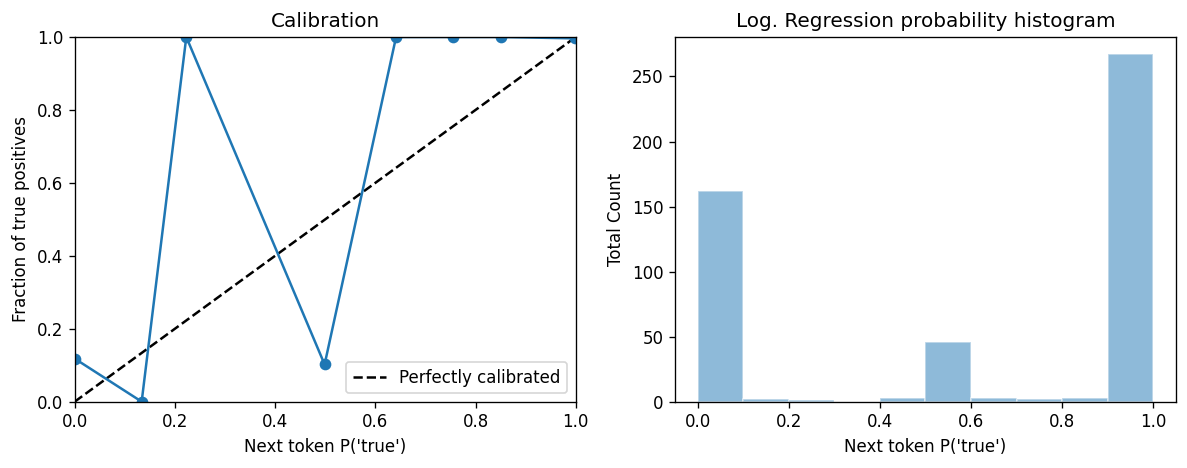

In [44]:
# P('true') next token probability from GPT 5.2
p_test = extracted_df['judgement_confidence_gpt'].to_numpy()

# NOTE: This is an important assumption you should think more about
# replace any NaN values with 0.5 (indicating maximum uncertainty)
p_test = np.nan_to_num(p_test, nan=0.5)

labels_test = labels

# Reliability diagram data
# strategy='quantile' ensures roughly equal counts per bin; 'uniform' uses fixed-width bins
frac_pos, mean_pred = calibration_curve(labels_test, p_test, n_bins=10, strategy='uniform')

brier = brier_score_loss(labels_test, p_test)
print(f"Brier score (lower is better): {brier:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# (1) Calibration diagram
ax[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax[0].plot(mean_pred, frac_pos, marker="o")
ax[0].set_xlabel("Next token P('true')")
ax[0].set_ylabel("Fraction of true positives")
ax[0].set_title("Calibration")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].legend()

# (2) Probability histogram
ax[1].hist(p_test, bins=10, range=(0, 1), edgecolor="white", alpha=0.5)
ax[1].set_xlabel("Next token P('true')")
ax[1].set_ylabel("Total Count")
ax[1].set_title("Log. Regression probability histogram")

plt.tight_layout()
plt.show()

#### With Llama logistic regression output

Brier score (lower is better): 0.0809


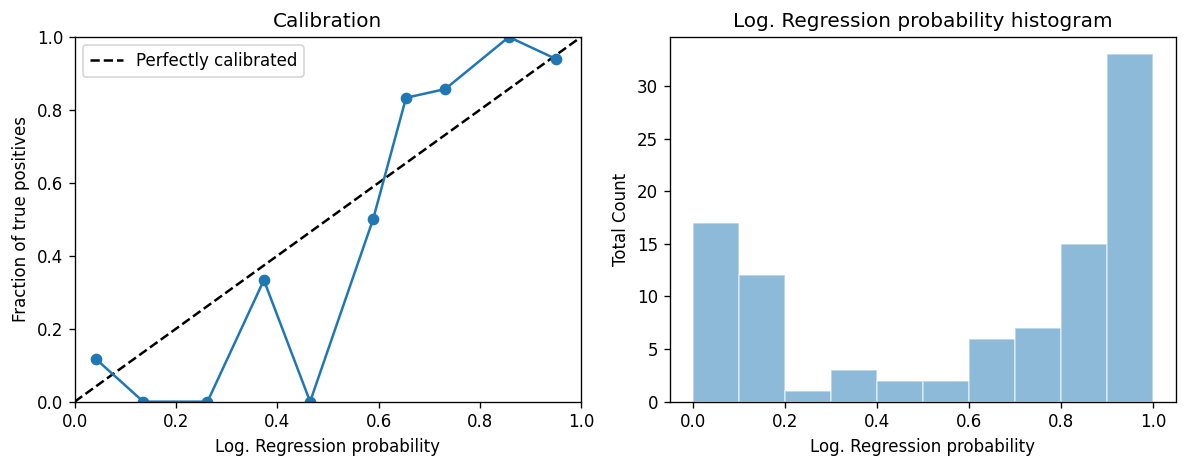

In [45]:
# Predicted probabilities for the positive class
p_test = log_reg.predict_proba(X_test)[:, 1]
labels_test = y_test

# Reliability diagram data
# strategy='quantile' ensures roughly equal counts per bin; 'uniform' uses fixed-width bins
frac_pos, mean_pred = calibration_curve(labels_test, p_test, n_bins=10, strategy='uniform')

brier = brier_score_loss(labels_test, p_test)
print(f"Brier score (lower is better): {brier:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# (1) Calibration diagram
ax[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax[0].plot(mean_pred, frac_pos, marker="o")
ax[0].set_xlabel("Log. Regression probability")
ax[0].set_ylabel("Fraction of true positives")
ax[0].set_title("Calibration")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].legend()

# (2) Probability histogram
ax[1].hist(p_test, bins=10, range=(0, 1), edgecolor="white", alpha=0.5)
ax[1].set_xlabel("Log. Regression probability")
ax[1].set_ylabel("Total Count")
ax[1].set_title("Log. Regression probability histogram")

plt.tight_layout()
plt.show()
